# TopoVein — Preprocessing & Skeletonization Exploration

**Branch:** `harsh`  
**Purpose:** Explore and validate preprocessing steps on FV-USM dataset before writing formal module code.  
**Dataset:** `Dataset/Published_database_FV-USM_Dec2013/1st_session/extractedvein/`  
**Note:** This is exploration only. Final `.py` code comes after Samiksha finalizes preprocessing.


## Cell 1 — Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from pathlib import Path

# Display images larger in notebook
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['image.cmap'] = 'gray'

print('All imports successful')

All imports successful


## Cell 2 — Dataset path setup

In [2]:
# Set your dataset root — adjust if your path is different
DATASET_ROOT = Path('../../Dataset/Published_database_FV-USM_Dec2013')
SESSION1_EXTRACTED = DATASET_ROOT / '1st_session' / 'extractedvein'
SESSION1_RAW = DATASET_ROOT / '1st_session' / 'raw_data'

# Verify the path exists
print('Extracted vein path exists:', SESSION1_EXTRACTED.exists())
print('Raw data path exists:', SESSION1_RAW.exists())

# List first 5 subject folders to confirm structure
folders = sorted(SESSION1_EXTRACTED.iterdir())
print('\nFirst 5 subject folders:')
for f in folders[:5]:
    print(' ', f.name)

Extracted vein path exists: True
Raw data path exists: True

First 5 subject folders:
  .DS_Store
  ._.DS_Store
  vein001_1
  vein001_2
  vein001_3


## Cell 3 — Load and visualize one raw image

Image shape: (300, 100, 3)
Image dtype: uint8
Min pixel value: 33
Max pixel value: 136
Channels identical (effectively grayscale): True


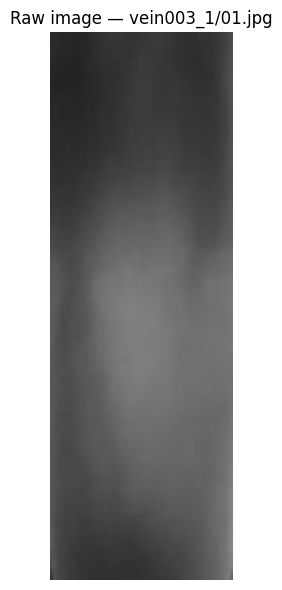

In [3]:
# Load subject 1, finger 1, image 1 from extractedvein
img_path = SESSION1_EXTRACTED / 'vein001_1' / '01.jpg'
img_raw = cv2.imread(str(img_path))

print('Image shape:', img_raw.shape)
print('Image dtype:', img_raw.dtype)
print('Min pixel value:', img_raw.min())
print('Max pixel value:', img_raw.max())

# Check if already grayscale (BGR with identical channels = grayscale saved as color)
if len(img_raw.shape) == 3:
    b, g, r = cv2.split(img_raw)
    channels_identical = np.array_equal(b, g) and np.array_equal(g, r)
    print('Channels identical (effectively grayscale):', channels_identical)

# Display
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))
plt.title('Raw image — vein003_1/01.jpg')
plt.axis('off')
plt.tight_layout()
plt.show()

## Cell 4 — Convert to grayscale

Grayscale shape: (300, 100)
Mean pixel value: 82.23


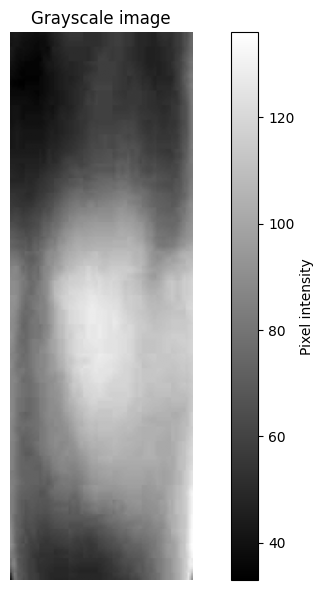

In [4]:
# Convert to grayscale
img_gray = cv2.cvtColor(img_raw, cv2.COLOR_BGR2GRAY)
print('Grayscale shape:', img_gray.shape)
print('Mean pixel value:', img_gray.mean().round(2))

plt.figure(figsize=(8, 6))
plt.imshow(img_gray)
plt.title('Grayscale image')
plt.colorbar(label='Pixel intensity')
plt.axis('off')
plt.tight_layout()
plt.show()

## Cell 5 — CLAHE enhancement (test different clipLimit values)

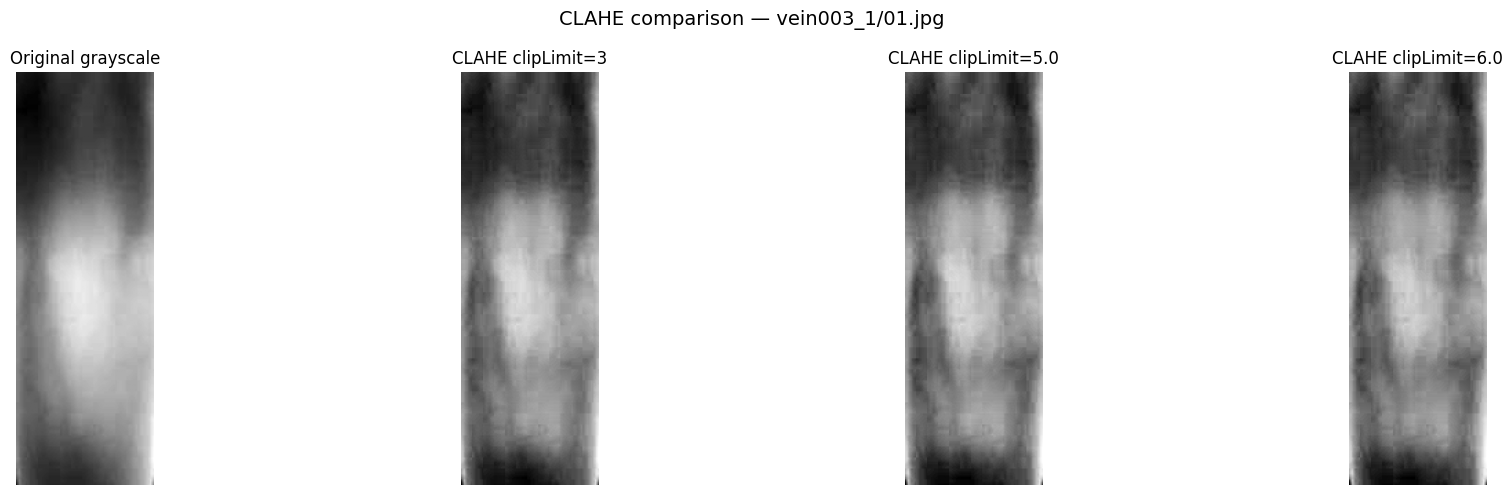

In [5]:
# Test 3 different CLAHE clipLimit values
clip_limits = [3, 5.0, 6.0]
tile_grid = (5,5)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_gray)
axes[0].set_title('Original grayscale')
axes[0].axis('off')

clahe_results = {}
for i, clip in enumerate(clip_limits):
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile_grid)
    enhanced = clahe.apply(img_gray)
    clahe_results[clip] = enhanced
    axes[i+1].imshow(enhanced)
    axes[i+1].set_title(f'CLAHE clipLimit={clip}')
    axes[i+1].axis('off')

plt.suptitle('CLAHE comparison — vein003_1/01.jpg', fontsize=14)
plt.tight_layout()
plt.show()

# NOTE: Look at which clipLimit gives the clearest vein contrast
# Update Notion observations table with what you see

## Cell 6 — Gaussian blur (noise removal)

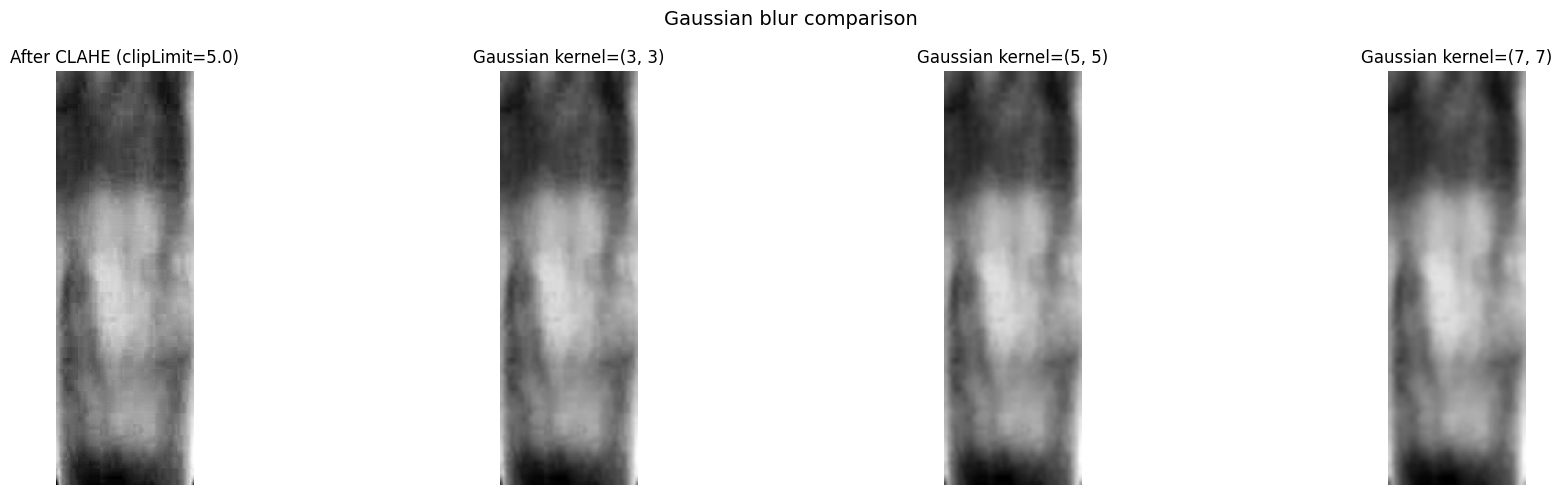

In [6]:
# Use best CLAHE result from above (default: clipLimit=2.0)
img_clahe = clahe_results[5.0]

# Test different Gaussian kernel sizes
kernels = [ (3,3),(5, 5), (7, 7)]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_clahe)
axes[0].set_title('After CLAHE (clipLimit=5.0)')
axes[0].axis('off')

blur_results = {}
for i, k in enumerate(kernels):
    blurred = cv2.GaussianBlur(img_clahe, k, 0)
    blur_results[k] = blurred
    axes[i+1].imshow(blurred)
    axes[i+1].set_title(f'Gaussian kernel={k}')
    axes[i+1].axis('off')

plt.suptitle('Gaussian blur comparison', fontsize=14)
plt.tight_layout()
plt.show()

## Cell 7 — Otsu binarization

Otsu threshold found: 111.0


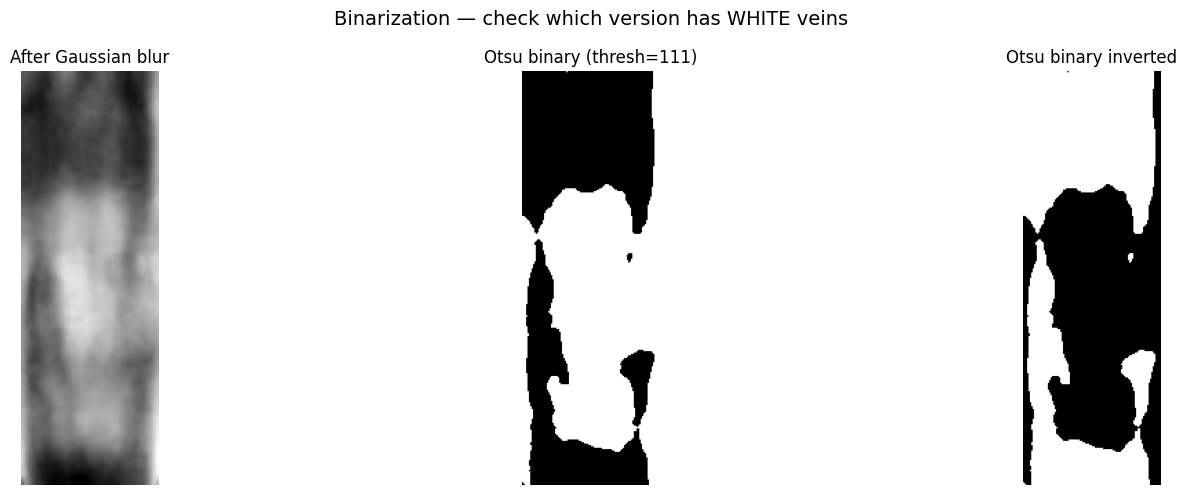

In [7]:
# Use best blur result (default: kernel (5,5))
img_blurred = blur_results[(7,7)]

# Otsu automatically finds best threshold
otsu_thresh, img_binary = cv2.threshold(
    img_blurred, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print(f'Otsu threshold found: {otsu_thresh}')

# Also try inverted binary (veins should be white)
_, img_binary_inv = cv2.threshold(
    img_blurred, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img_blurred)
axes[0].set_title('After Gaussian blur')
axes[0].axis('off')

axes[1].imshow(img_binary)
axes[1].set_title(f'Otsu binary (thresh={int(otsu_thresh)})')
axes[1].axis('off')

axes[2].imshow(img_binary_inv)
axes[2].set_title(f'Otsu binary inverted')
axes[2].axis('off')

plt.suptitle('Binarization — check which version has WHITE veins', fontsize=14)
plt.tight_layout()
plt.show()

# NOTE: Skeletonization needs veins to be WHITE (255) on black (0) background
# Choose the correct version above and use it in Cell 8

## Cell 8 — Skeletonization

Skeleton shape: (300, 100)
Skeleton white pixels (vein pixels): 564
Original binary white pixels: 15024
Thinning ratio: 0.038


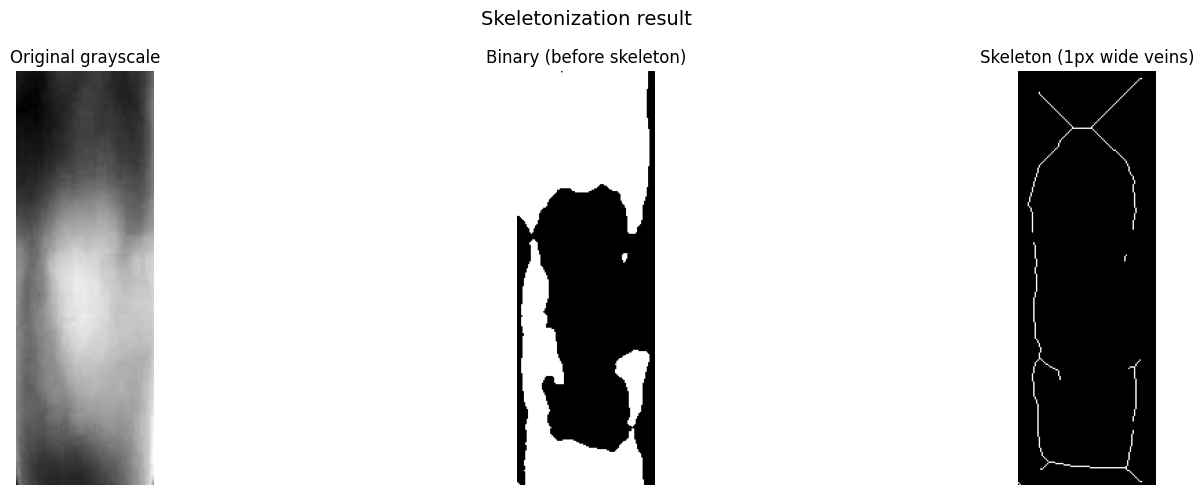

## Cell 9 — Overlay skeleton on original image

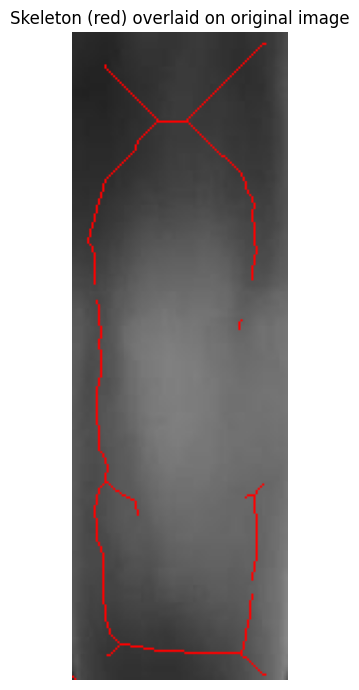

In [9]:
# Create colour overlay: skeleton in red on top of grayscale
img_overlay = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
img_overlay[skeleton] = [0, 0, 255]  # BGR: red

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(img_overlay, cv2.COLOR_BGR2RGB))
plt.title('Skeleton (red) overlaid on original image')
plt.axis('off')
plt.tight_layout()
plt.show()

# This is your visual validation:
# The red lines should trace the centre of the dark veins in the original image

## Cell 10 — Test on multiple subjects

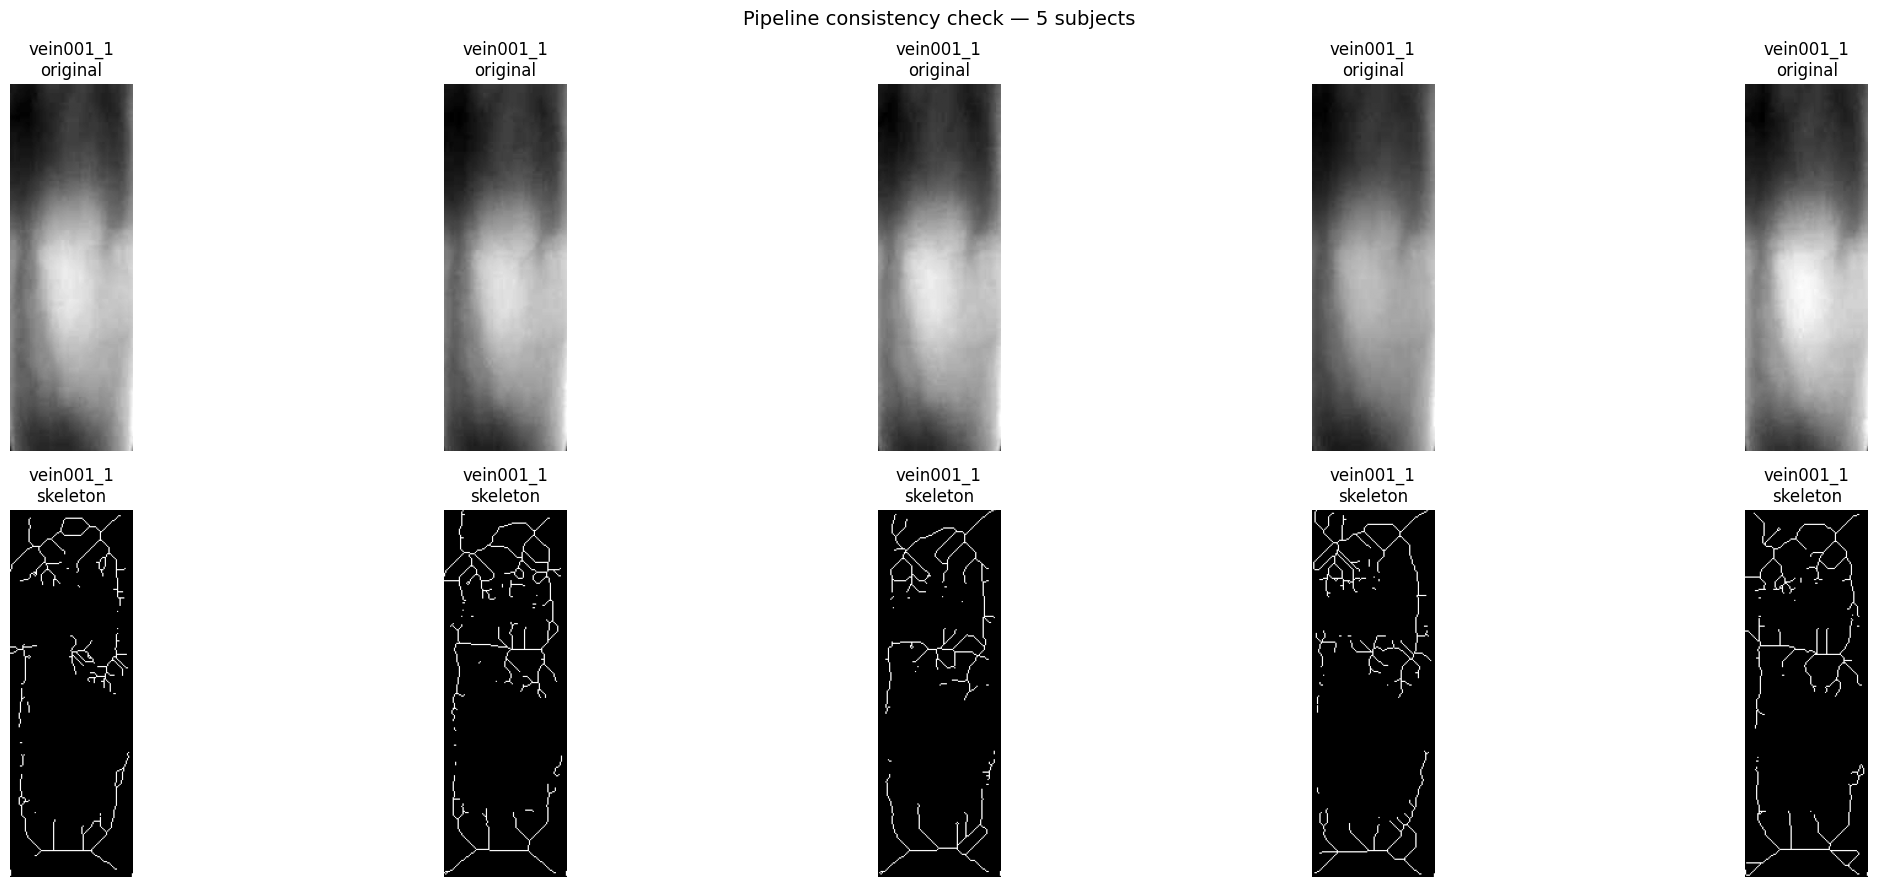

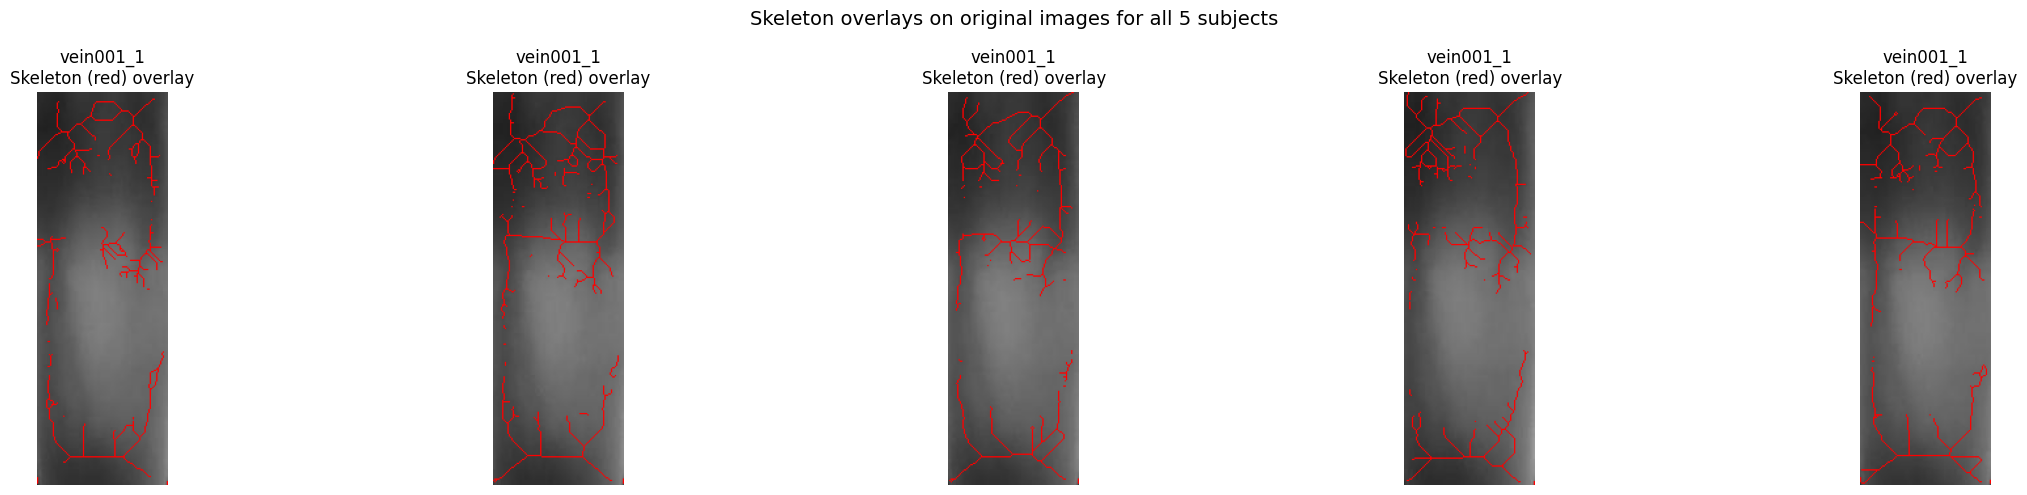

In [13]:
def full_pipeline(img_path, clip_limit=30.0, kernel=(3,1)):
    """
    Run full preprocessing + skeletonization on one image.
    Returns: (original_gray, skeleton)
    """
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(9,3))
    enhanced = clahe.apply(gray)
    blurred = cv2.GaussianBlur(enhanced, kernel, 0)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    skeleton = skeletonize(binary > 0)
    return gray, skeleton


# Test on 5 different subjects
test_images = [
    SESSION1_EXTRACTED / 'vein001_1' / '01.jpg',
    SESSION1_EXTRACTED / 'vein001_1' / '02.jpg',
    SESSION1_EXTRACTED / 'vein001_1' / '03.jpg',
    SESSION1_EXTRACTED / 'vein001_1' / '04.jpg',
    SESSION1_EXTRACTED / 'vein001_1' / '05.jpg',
]

fig, axes = plt.subplots(2, 5, figsize=(24, 9))

# Store processed results for overlay visualization
processed_results = []

for i, path in enumerate(test_images):
    gray, skel = full_pipeline(path)
    skel_uint8 = (skel * 255).astype(np.uint8)
    label = path.parts[-2]  # e.g. vein001_1
    
    # Store results for later overlay visualization
    processed_results.append((gray, skel, label))

    axes[0, i].imshow(gray)
    axes[0, i].set_title(f'{label}\noriginal')
    axes[0, i].axis('off')

    axes[1, i].imshow(skel_uint8)
    axes[1, i].set_title(f'{label}\nskeleton')
    axes[1, i].axis('off')

plt.suptitle('Pipeline consistency check — 5 subjects', fontsize=14)
plt.tight_layout()
plt.show()

# Create overlay visualization for all 5 images
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, (gray, skel, label) in enumerate(processed_results):
    # Create overlay: skeleton (red) on original image
    img_overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    img_overlay[skel] = [0, 0, 255]  # BGR: red
    
    axes[i].imshow(cv2.cvtColor(img_overlay, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'{label}\nSkeleton (red) overlay')
    axes[i].axis('off')

plt.suptitle('Skeleton overlays on original images for all 5 subjects', fontsize=14)
plt.tight_layout()
plt.show()

# OBSERVE:
# Are all skeletons clean 1px lines?
# Are the vein structures visible and distinct?
# Is there too much noise (spurious branches)?
# Update Notion observation table with your findings


## Cell 11 — Compare extractedvein vs raw_data

Extracted path exists: True
Raw path exists: True


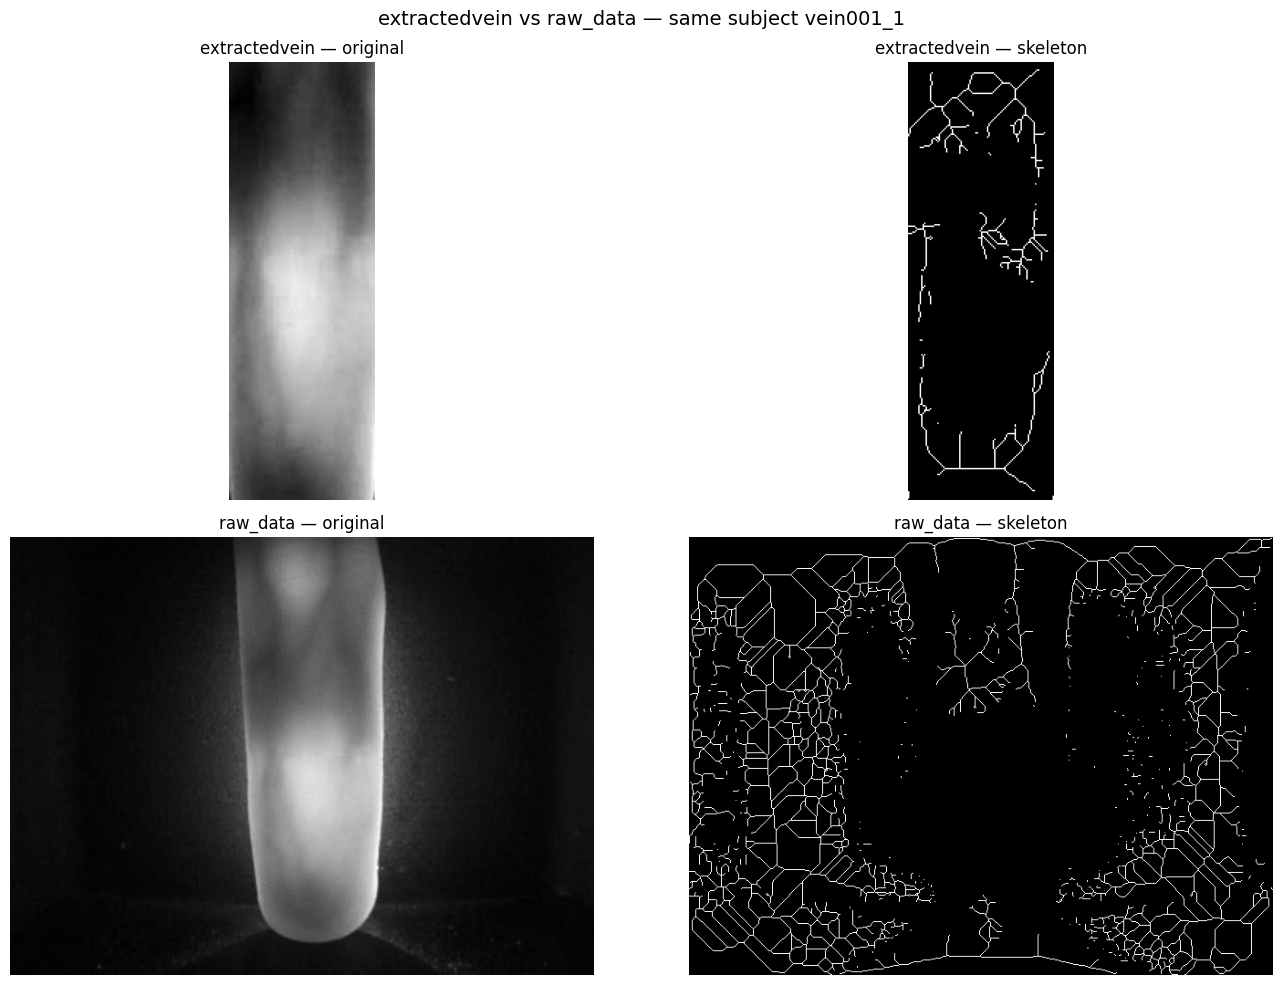

In [11]:
# Same subject, compare extractedvein (pre-processed) vs raw_data
# FV-USM raw_data folder uses different naming: 001_1 not vein001_1

extracted_path = SESSION1_EXTRACTED / 'vein001_1' / '01.jpg'
raw_path = SESSION1_RAW / '001_1' / '01.jpg'

print('Extracted path exists:', extracted_path.exists())
print('Raw path exists:', raw_path.exists())

if extracted_path.exists() and raw_path.exists():
    gray_ext, skel_ext = full_pipeline(extracted_path)
    gray_raw, skel_raw = full_pipeline(raw_path)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].imshow(gray_ext)
    axes[0, 0].set_title('extractedvein — original')
    axes[0, 0].axis('off')

    axes[0, 1].imshow((skel_ext * 255).astype(np.uint8))
    axes[0, 1].set_title('extractedvein — skeleton')
    axes[0, 1].axis('off')

    axes[1, 0].imshow(gray_raw)
    axes[1, 0].set_title('raw_data — original')
    axes[1, 0].axis('off')

    axes[1, 1].imshow((skel_raw * 255).astype(np.uint8))
    axes[1, 1].set_title('raw_data — skeleton')
    axes[1, 1].axis('off')

    plt.suptitle('extractedvein vs raw_data — same subject vein001_1', fontsize=14)
    plt.tight_layout()
    plt.show()

## Cell 12 — Final parameter decision

After running all cells above, fill in your final chosen parameters here.
These will be handed to Samiksha for her formal preprocessing module.

In [12]:
# FILL THIS IN after your experiments above

FINAL_PARAMS = {
    'clahe_clip_limit': 2.0,       # update after Cell 5
    'clahe_tile_grid': (8, 8),     # keep as is
    'gaussian_kernel': (5, 5),     # update after Cell 6
    'binarization': 'otsu_inv',    # otsu or otsu_inv depending on Cell 7
    'dataset': 'extractedvein',    # update after Cell 11 comparison
    'session': '1st_session',
}

print('Final parameters to hand to Samiksha:')
for k, v in FINAL_PARAMS.items():
    print(f'  {k}: {v}')

print('\nUpdate these in Notion: Harsh page -> Notebook Exploration page -> Parameters finalized for Samiksha')

Final parameters to hand to Samiksha:
  clahe_clip_limit: 2.0
  clahe_tile_grid: (8, 8)
  gaussian_kernel: (5, 5)
  binarization: otsu_inv
  dataset: extractedvein
  session: 1st_session

Update these in Notion: Harsh page -> Notebook Exploration page -> Parameters finalized for Samiksha
